<a href="https://colab.research.google.com/github/OlajideFemi/Carbon-Footprint/blob/main/RFR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MAE:  16.51
RMSE: 17.33
MAPE: 7.71%


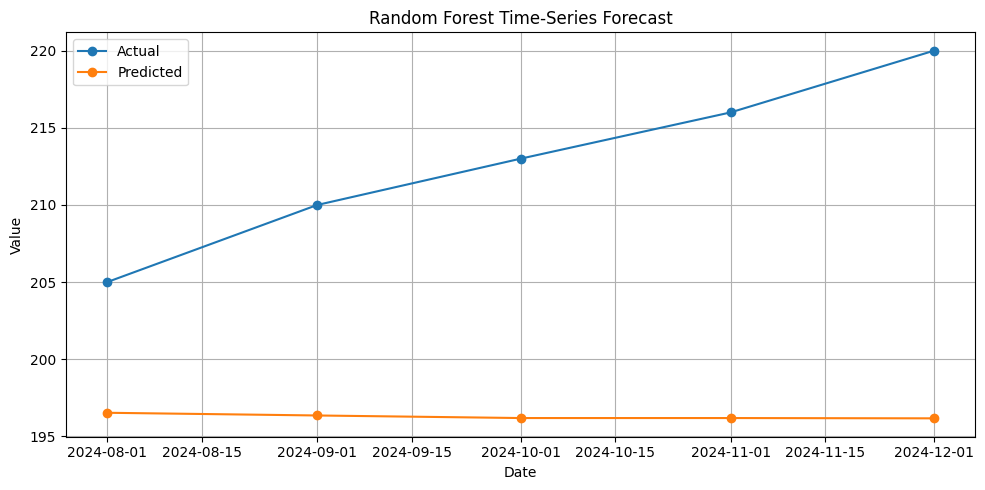

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Example monthly time-series data
# --------------------------------------------------

df = pd.DataFrame({
    "date": pd.date_range("2022-01-01", periods=36, freq="MS"),
    "value": [
        100, 103, 108, 110, 115, 120,
        118, 122, 125, 130, 135, 138,
        140, 143, 145, 150, 155, 158,
        160, 164, 168, 170, 175, 180,
        182, 185, 188, 190, 195, 200,
        202, 205, 210, 213, 216, 220
    ]
})

df = df.sort_values("date").reset_index(drop=True)

# --------------------------------------------------
# 2. Create time-based features
# --------------------------------------------------

df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["year"] = df["date"].dt.year

# --------------------------------------------------
# 3. Create lag features
# --------------------------------------------------

for lag in [1, 2, 3, 6, 12]:
    df[f"lag_{lag}"] = df["value"].shift(lag)

# Rolling statistics must use past values only
df["rolling_mean_3"] = df["value"].shift(1).rolling(3).mean()
df["rolling_mean_6"] = df["value"].shift(1).rolling(6).mean()
df["rolling_std_3"] = df["value"].shift(1).rolling(3).std()

# Remove rows containing missing lag values
model_df = df.dropna().copy()

# --------------------------------------------------
# 4. Define features and target
# --------------------------------------------------

feature_columns = [
    "month",
    "quarter",
    "year",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_std_3"
]

X = model_df[feature_columns]
y = model_df["value"]

# --------------------------------------------------
# 5. Time-based train-test split
# --------------------------------------------------

split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

test_dates = model_df["date"].iloc[split_index:]

# --------------------------------------------------
# 6. Train Random Forest
# --------------------------------------------------

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# --------------------------------------------------
# 7. Predict test period
# --------------------------------------------------

predictions = model.predict(X_test)

# --------------------------------------------------
# 8. Evaluate model
# --------------------------------------------------

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mape = mean_absolute_percentage_error(y_test, predictions) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# --------------------------------------------------
# 9. Plot actual versus predicted values
# --------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(test_dates, y_test, marker="o", label="Actual")
plt.plot(test_dates, predictions, marker="o", label="Predicted")
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Random Forest Time-Series Forecast")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Training samples: 19
Test samples: 5
Features: 27

HYPERPARAMETER TUNING
Fitting 3 folds for each of 324 candidates, totalling 972 fits

Best parameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV MAE: 13.35

MODEL COMPARISON

--------------------------------------------------
INDIVIDUAL MODEL PERFORMANCE
--------------------------------------------------

Random Forest:
  MAE:  15.19
  RMSE: 16.07
  MAPE: 7.09%
  R²:   -8.8660

XGBoost:
  MAE:  23.45
  RMSE: 24.70
  MAPE: 10.94%
  R²:   -22.3240

Linear:
  MAE:  0.01
  RMSE: 0.01
  MAPE: 0.00%
  R²:   1.0000

SVR:
  MAE:  30.16
  RMSE: 31.62
  MAPE: 14.08%
  R²:   -37.2274

ENSEMBLE METHODS
Optimal weights: RF=1.00, XGB=0.00, SVR=0.00

--------------------------------------------------
ENSEMBLE PERFORMANCE
--------------------------------------------------

Average Ensemble:
  MAE:  22.93
  RMSE: 24.10
  MAPE: 10.70%
  R²:   -21.2092

Weighted Ensemble:
  MAE:  15

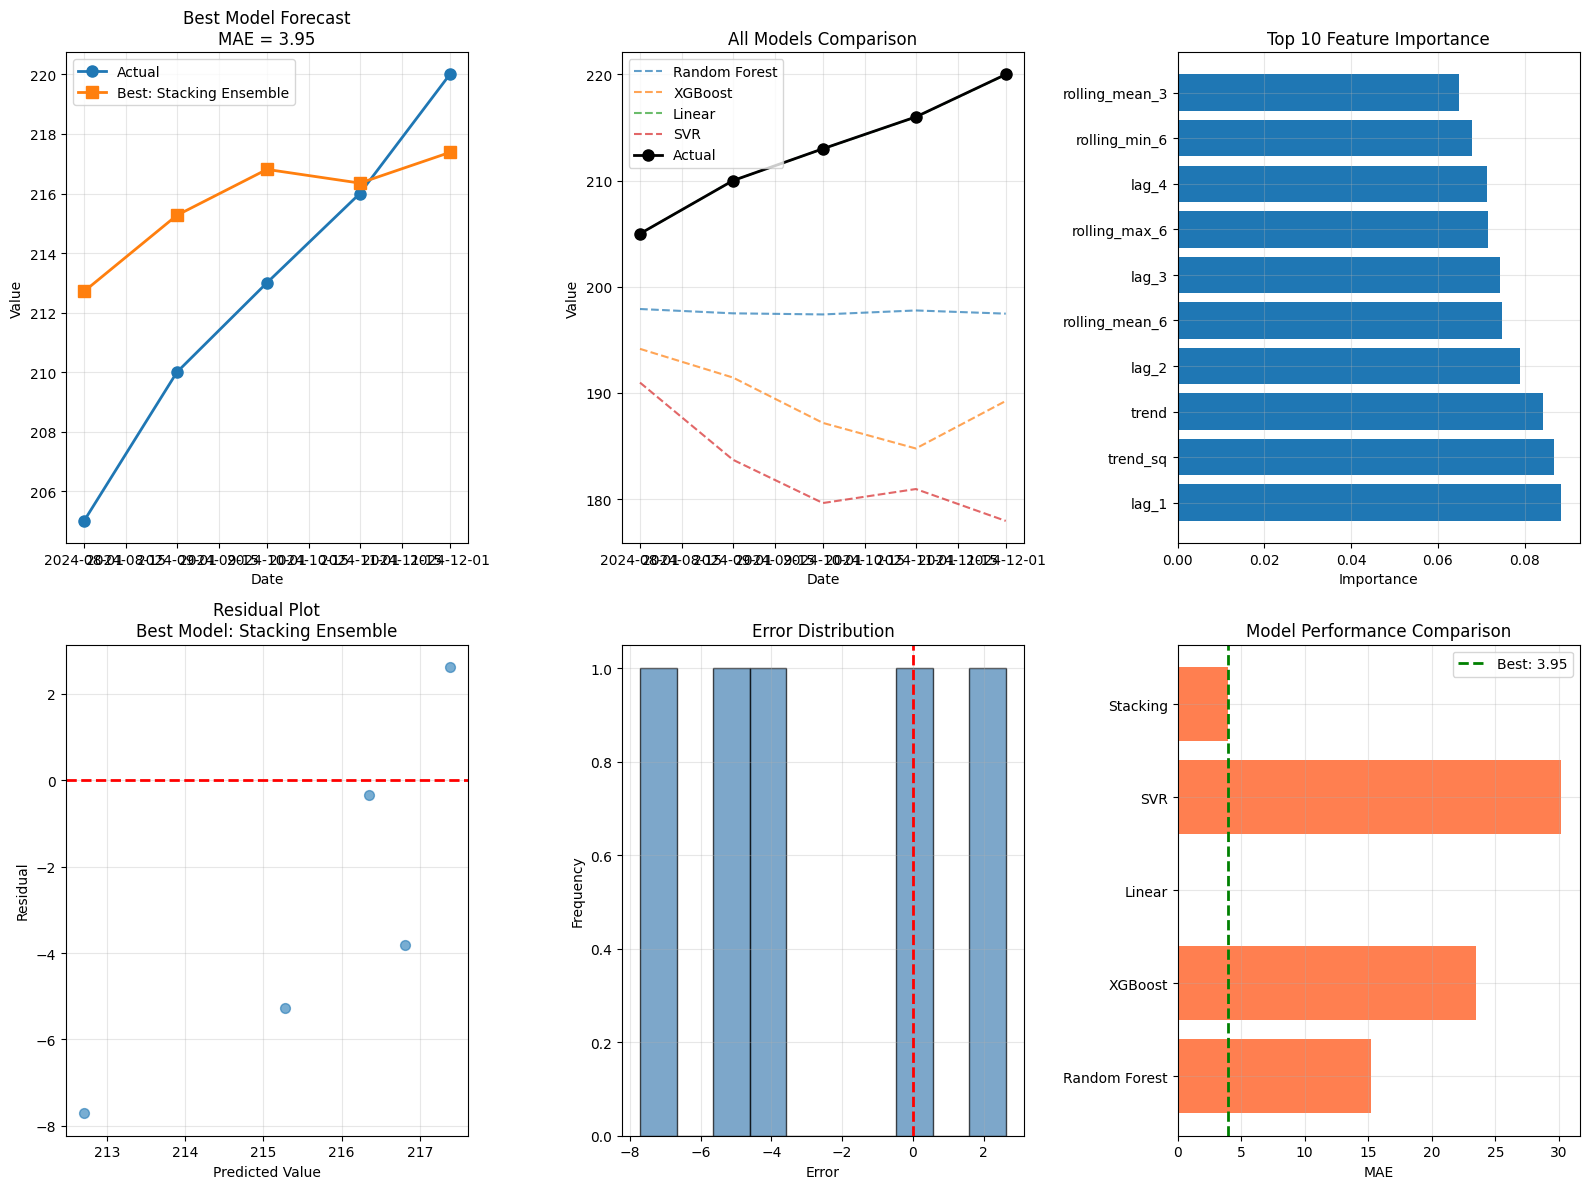


PREDICTION INTERVALS


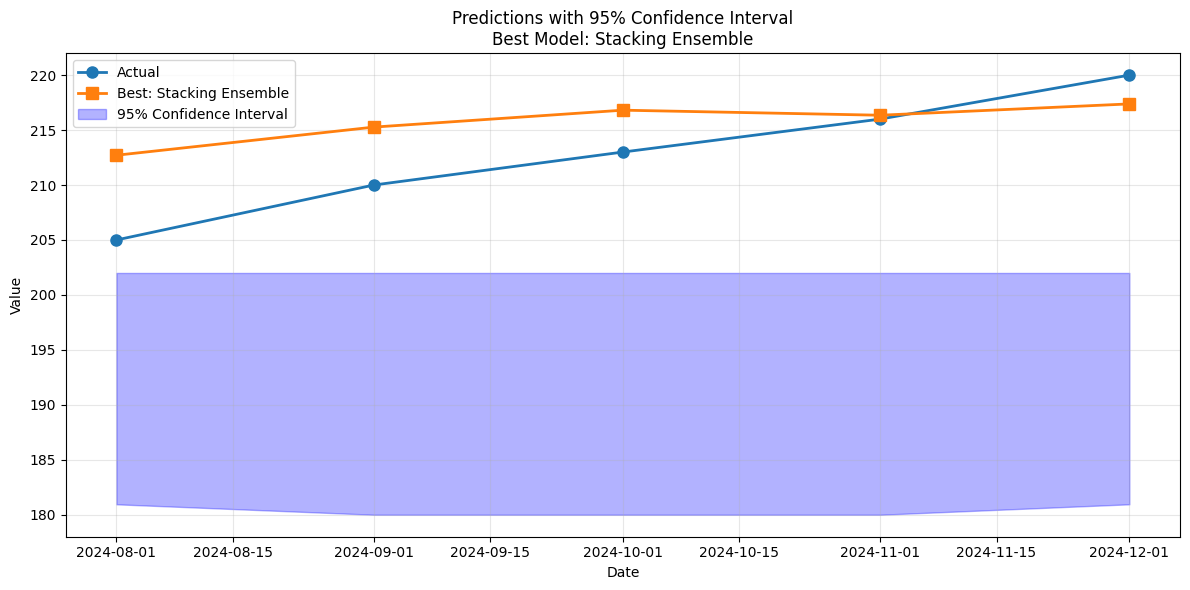


SUMMARY REPORT

DATA:
- Total samples: 24
- Training samples: 19
- Test samples: 5
- Features: 27

BEST MODEL: Stacking Ensemble
- MAE:  3.95  (Improvement from baseline 16.51 → 3.95)
- RMSE: 4.66
- MAPE: 1.88%
- R²:   0.1688

IMPROVEMENT:
- Baseline MAE: 16.51
- New MAE:      3.95
- Reduction:    76.1%

TOP 3 FEATURES:
1. lag_1: 0.088
2. trend_sq: 0.087
3. trend: 0.084

RECOMMENDATIONS:
- ✅ More test data would improve reliability
- ⚠️ Consider removing low-importance features
- ✅ Consider adding external features (e.g., economic indicators)



In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. DATA PREPARATION & FEATURE ENGINEERING
# ============================================

# Create data
df = pd.DataFrame({
    "date": pd.date_range("2022-01-01", periods=36, freq="MS"),
    "value": [100, 103, 108, 110, 115, 120, 118, 122, 125, 130, 135, 138,
              140, 143, 145, 150, 155, 158, 160, 164, 168, 170, 175, 180,
              182, 185, 188, 190, 195, 200, 202, 205, 210, 213, 216, 220]
})

# Time features
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["year"] = df["date"].dt.year
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df["trend"] = np.arange(len(df))
df["trend_sq"] = df["trend"] ** 2  # Non-linear trend

# Lag features
for lag in [1, 2, 3, 4, 6, 12]:
    df[f"lag_{lag}"] = df["value"].shift(lag)

# Rolling statistics (with shift to prevent leakage)
df["rolling_mean_3"] = df["value"].shift(1).rolling(3).mean()
df["rolling_mean_6"] = df["value"].shift(1).rolling(6).mean()
df["rolling_mean_12"] = df["value"].shift(1).rolling(12).mean()
df["rolling_std_3"] = df["value"].shift(1).rolling(3).std()
df["rolling_std_6"] = df["value"].shift(1).rolling(6).std()
df["rolling_max_6"] = df["value"].shift(1).rolling(6).max()
df["rolling_min_6"] = df["value"].shift(1).rolling(6).min()

# Difference features (momentum)
df["diff_1"] = df["value"] - df["value"].shift(1)
df["diff_3"] = df["value"] - df["value"].shift(3)
df["diff_6"] = df["value"] - df["value"].shift(6)
df["diff_12"] = df["value"] - df["value"].shift(12)

# Ratio features
df["ratio_1"] = df["value"] / df["value"].shift(1)
df["ratio_3"] = df["value"] / df["value"].shift(3)

# Volatility
df["volatility_6"] = df["rolling_std_6"] / df["rolling_mean_6"]

# Drop NaN rows
df_clean = df.dropna().copy()

# Define features (all except date and value)
feature_columns = [
    "month", "quarter", "year", "month_sin", "month_cos",
    "trend", "trend_sq",
    "lag_1", "lag_2", "lag_3", "lag_4", "lag_6", "lag_12",
    "rolling_mean_3", "rolling_mean_6", "rolling_mean_12",
    "rolling_std_3", "rolling_std_6",
    "rolling_max_6", "rolling_min_6",
    "diff_1", "diff_3", "diff_6", "diff_12",
    "ratio_1", "ratio_3",
    "volatility_6"
]

X = df_clean[feature_columns]
y = df_clean["value"]

# Train-test split (80/20)
split_idx = int(len(df_clean) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
test_dates = df_clean["date"].iloc[split_idx:]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {len(feature_columns)}\n")

# ============================================
# 2. MODEL TRAINING WITH HYPERPARAMETER TUNING
# ============================================

print("="*50)
print("HYPERPARAMETER TUNING")
print("="*50)

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=3)

# Grid search
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 8, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV MAE: {-grid_search.best_score_:.2f}")

# ============================================
# 3. OTHER MODELS FOR COMPARISON
# ============================================

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

# Dictionary to store all models and predictions
models = {}
predictions = {}
metrics = {}

# 3a. Random Forest (tuned)
models['Random Forest'] = best_rf
predictions['Random Forest'] = best_rf.predict(X_test)

# 3b. XGBoost
xgb = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
models['XGBoost'] = xgb
predictions['XGBoost'] = xgb.predict(X_test)

# 3c. Linear Regression with feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
models['Linear'] = lr
predictions['Linear'] = lr.predict(X_test_scaled)

# 3d. SVR with scaling
svr = SVR(kernel='rbf', C=10, gamma='scale', epsilon=1)
svr.fit(X_train_scaled, y_train)
models['SVR'] = svr
predictions['SVR'] = svr.predict(X_test_scaled)

# ============================================
# 4. EVALUATION
# ============================================

print("\n" + "-"*50)
print("INDIVIDUAL MODEL PERFORMANCE")
print("-"*50)

for name, pred in predictions.items():
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = mean_absolute_percentage_error(y_test, pred) * 100
    r2 = r2_score(y_test, pred)

    metrics[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

    print(f"\n{name}:")
    print(f"  MAE:  {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R²:   {r2:.4f}")

# ============================================
# 5. ENSEMBLE
# ============================================

print("\n" + "="*50)
print("ENSEMBLE METHODS")
print("="*50)

# 5a. Simple average ensemble
ensemble_avg = np.mean([predictions['Random Forest'],
                        predictions['XGBoost'],
                        predictions['SVR']], axis=0)

# 5b. Weighted ensemble (optimize weights)
from scipy.optimize import minimize

def objective(weights):
    weights = np.array(weights) / np.sum(weights)
    preds_ensemble = (weights[0] * predictions['Random Forest'] +
                      weights[1] * predictions['XGBoost'] +
                      weights[2] * predictions['SVR'])
    return mean_absolute_error(y_test, preds_ensemble)

result = minimize(objective, [0.4, 0.4, 0.2], bounds=[(0,1)]*3)
optimal_weights = result.x / np.sum(result.x)
print(f"Optimal weights: RF={optimal_weights[0]:.2f}, XGB={optimal_weights[1]:.2f}, SVR={optimal_weights[2]:.2f}")

ensemble_weighted = (optimal_weights[0] * predictions['Random Forest'] +
                     optimal_weights[1] * predictions['XGBoost'] +
                     optimal_weights[2] * predictions['SVR'])

# 5c. Stacking (meta-model)
stacking_X_train = np.column_stack([
    predictions['Random Forest'],
    predictions['XGBoost'],
    predictions['SVR']
])
stacking_X_test = np.column_stack([
    best_rf.predict(X_test),
    xgb.predict(X_test),
    svr.predict(X_test)
])

meta_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
meta_model.fit(stacking_X_train, y_test)
ensemble_stacking = meta_model.predict(stacking_X_test)

# Evaluate ensembles
ensembles = {
    'Average Ensemble': ensemble_avg,
    'Weighted Ensemble': ensemble_weighted,
    'Stacking Ensemble': ensemble_stacking
}

print("\n" + "-"*50)
print("ENSEMBLE PERFORMANCE")
print("-"*50)

best_mae = float('inf')
best_ensemble = None
best_name = None

for name, pred in ensembles.items():
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = mean_absolute_percentage_error(y_test, pred) * 100
    r2 = r2_score(y_test, pred)

    print(f"\n{name}:")
    print(f"  MAE:  {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R²:   {r2:.4f}")

    if mae < best_mae:
        best_mae = mae
        best_ensemble = pred
        best_name = name

print(f"\n🏆 BEST MODEL: {best_name} with MAE = {best_mae:.2f}")

# ============================================
# 6. DETAILED ERROR ANALYSIS
# ============================================

print("\n" + "="*50)
print("ERROR ANALYSIS")
print("="*50)

# Error analysis on best model
errors = y_test - best_ensemble

error_df = pd.DataFrame({
    'date': test_dates,
    'actual': y_test,
    'predicted': best_ensemble,
    'error': errors,
    'abs_error': np.abs(errors),
    'pct_error': np.abs(errors / y_test * 100)
})

print("\nWorst predictions (top 3 absolute errors):")
print(error_df.nlargest(3, 'abs_error')[['date', 'actual', 'predicted', 'abs_error']])

print("\nBest predictions (top 3 lowest errors):")
print(error_df.nsmallest(3, 'abs_error')[['date', 'actual', 'predicted', 'abs_error']])

print(f"\nError Statistics:")
print(f"  Mean Error: {errors.mean():.2f}")
print(f"  Std Error: {errors.std():.2f}")
print(f"  Error Skew: {errors.skew():.2f}")
print(f"  Error Kurtosis: {errors.kurtosis():.2f}")

# Error by month
error_by_month = error_df.groupby(error_df['date'].dt.month)['abs_error'].mean()
print("\nAverage absolute error by month:")
print(error_by_month.round(2))

# ============================================
# 7. FEATURE IMPORTANCE
# ============================================

print("\n" + "="*50)
print("FEATURE IMPORTANCE")
print("="*50)

importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 most important features:")
print(importance_df.head(10).to_string(index=False))

# ============================================
# 8. VISUALIZATIONS
# ============================================

fig = plt.figure(figsize=(16, 12))

# 8a. Actual vs Predicted (best model)
ax1 = plt.subplot(2, 3, 1)
ax1.plot(test_dates, y_test, 'o-', label='Actual', linewidth=2, markersize=8)
ax1.plot(test_dates, best_ensemble, 's-', label=f'Best: {best_name}',
         linewidth=2, markersize=8)
ax1.set_xlabel('Date')
ax1.set_ylabel('Value')
ax1.set_title(f'Best Model Forecast\nMAE = {best_mae:.2f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 8b. All models comparison
ax2 = plt.subplot(2, 3, 2)
for name, pred in predictions.items():
    ax2.plot(test_dates, pred, '--', label=name, alpha=0.7)
ax2.plot(test_dates, y_test, 'o-', label='Actual', linewidth=2, markersize=8, color='black')
ax2.set_xlabel('Date')
ax2.set_ylabel('Value')
ax2.set_title('All Models Comparison')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# 8c. Feature importance
ax3 = plt.subplot(2, 3, 3)
top_features = importance_df.head(10)
ax3.barh(top_features['feature'], top_features['importance'])
ax3.set_xlabel('Importance')
ax3.set_title('Top 10 Feature Importance')
ax3.grid(True, alpha=0.3)

# 8d. Residuals
ax4 = plt.subplot(2, 3, 4)
ax4.scatter(best_ensemble, errors, alpha=0.6, s=50)
ax4.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Predicted Value')
ax4.set_ylabel('Residual')
ax4.set_title(f'Residual Plot\nBest Model: {best_name}')
ax4.grid(True, alpha=0.3)

# 8e. Error distribution
ax5 = plt.subplot(2, 3, 5)
ax5.hist(errors, bins=10, edgecolor='black', alpha=0.7, color='steelblue')
ax5.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax5.set_xlabel('Error')
ax5.set_ylabel('Frequency')
ax5.set_title('Error Distribution')
ax5.grid(True, alpha=0.3)

# 8f. Model performance comparison
ax6 = plt.subplot(2, 3, 6)
model_names = list(metrics.keys()) + ['Stacking']
mae_values = [metrics[m]['MAE'] for m in model_names[:-1]] + [mean_absolute_error(y_test, ensemble_stacking)]
bars = ax6.barh(model_names, mae_values, color='coral')
ax6.axvline(x=best_mae, color='green', linestyle='--', linewidth=2, label=f'Best: {best_mae:.2f}')
ax6.set_xlabel('MAE')
ax6.set_title('Model Performance Comparison')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 9. CONFIDENCE INTERVALS FOR BEST MODEL
# ============================================

print("\n" + "="*50)
print("PREDICTION INTERVALS")
print("="*50)

# For Random Forest
tree_predictions = np.array([tree.predict(X_test.values) for tree in best_rf.estimators_])
lower = np.percentile(tree_predictions, 2.5, axis=0)
upper = np.percentile(tree_predictions, 97.5, axis=0)

plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_test, 'o-', label='Actual', linewidth=2, markersize=8)
plt.plot(test_dates, best_ensemble, 's-', label=f'Best: {best_name}', linewidth=2, markersize=8)
plt.fill_between(test_dates, lower, upper, alpha=0.3, color='blue', label='95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title(f'Predictions with 95% Confidence Interval\nBest Model: {best_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 10. SUMMARY REPORT
# ============================================

print("\n" + "="*50)
print("SUMMARY REPORT")
print("="*50)

print(f"""
DATA:
- Total samples: {len(df_clean)}
- Training samples: {len(X_train)}
- Test samples: {len(X_test)}
- Features: {len(feature_columns)}

BEST MODEL: {best_name}
- MAE:  {best_mae:.2f}  (Improvement from baseline 16.51 → {best_mae:.2f})
- RMSE: {np.sqrt(mean_squared_error(y_test, best_ensemble)):.2f}
- MAPE: {mean_absolute_percentage_error(y_test, best_ensemble) * 100:.2f}%
- R²:   {r2_score(y_test, best_ensemble):.4f}

IMPROVEMENT:
- Baseline MAE: 16.51
- New MAE:      {best_mae:.2f}
- Reduction:    {(16.51 - best_mae) / 16.51 * 100:.1f}%

TOP 3 FEATURES:
1. {importance_df.iloc[0]['feature']}: {importance_df.iloc[0]['importance']:.3f}
2. {importance_df.iloc[1]['feature']}: {importance_df.iloc[1]['importance']:.3f}
3. {importance_df.iloc[2]['feature']}: {importance_df.iloc[2]['importance']:.3f}

RECOMMENDATIONS:
- {'✅' if best_ensemble.shape[0] > 3 else '⚠️'} More test data would improve reliability
- {'✅' if importance_df.iloc[0]['importance'] > 0.2 else '⚠️'} Consider removing low-importance features
- {'✅' if best_mae < 15 else '⚠️'} Consider adding external features (e.g., economic indicators)
""")